In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import json
import sys
import os
import scipy.cluster.hierarchy as sch
import random
import logging
import torch
from torch.utils.data import DataLoader

from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence

from collections import defaultdict
from typing import Union, List

from typing import Dict, Any, Optional, Tuple
from tqdm import tqdm
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.model_selection import KFold



In [21]:
"""
Assistments Data Processing Script

This script processes the Assistments dataset for Bayesian Knowledge Tracing (BKT) or other
educational analytics tasks. It includes functions to clean, filter, and transform the data,
generate relevant statistics, and save the processed results.

Main Features:
- Filters data based on sequence length and minimum thresholds for problems and skills.
- Converts the dataset into a format suitable for BKT models.
- Saves the processed data and skill dictionary for further analysis.

Functions:
- clean_assistments_data: Cleans and processes the raw dataset.
- return_assistments_dict_bkt: Converts processed data into a BKT-compatible format.
- _save_dataframe: Helper function to save DataFrames and log their status.
"""


class KTDataset():
    def __init__(self,
                 df_answers,
                 df_skill_names,
                 renumber_skill_ids=True,
                 prepare_BKT=False,
                 prepare_DKT=False,
                 additional_columns=None):

        self.df_answers = df_answers
        self.df_skill_names = df_skill_names
        self.num_skills = len(df_skill_names)
        self.BKT_datadict = None
        self.DKT_datadict = None
        self.additional_columns = additional_columns
        self.num_other = 1 + (len(additional_columns) if additional_columns is not None else 0)

        if renumber_skill_ids:
            # Map original skill IDs to a continuous range starting from 1
            unique_skill_ids = sorted(df_skill_names['skill_id'].astype(int).unique())
            self.skill_id_mapping = {original_id: new_id for new_id, original_id in enumerate(unique_skill_ids, start=1)}
            # Apply the mapping to create the new column
            df_skill_names['skill_ids_renumbered'] = df_skill_names['skill_id'].map(self.skill_id_mapping)
        else:
            self.skill_id_mapping = None

        if prepare_BKT:
            self.create_BKT_datadict()

        if prepare_DKT:
            self.create_DKT_datadict()


    def return_ordered_ids(self, ids: Union[int, str, List[int], List[str]]) -> Union[int, List[int]]:
        """
        Returns renumbered skill IDs based on the mapping.

        Args:
            ids (Union[int, str, List[int], List[str]]): Original skill ID(s) to be renumbered.

        Returns:
            Union[int, List[int]]: Renumbered skill ID(s).
        """

        if isinstance(ids, (int, str)):
            return self.skill_id_mapping[int(ids)]
        elif isinstance(ids, list):
            return [self.skill_id_mapping[int(id)] for id in ids]
        else:
            raise TypeError("IDs must be an int, str, or a list of int/str.")


    def return_original_ids(self, ids: Union[int, str, List[int], List[str]]) -> Union[int, List[int]]:
        """
        Returns original skill IDs based on the renumbered skill IDs.

        Args:
            ids (Union[int, str, List[int], List[str]]): Renumbered skill ID(s) to be mapped back to the original IDs.

        Returns:
            Union[int, str, List[int], List[str]]: Original skill ID(s).
        """

        if isinstance(ids, (int, str)):
            return self.original_id_mapping.get(int(ids), None)  # Convert to integer for lookup
        elif isinstance(ids, list):
            return [self.original_id_mapping.get(int(id), None) for id in ids]  # Convert each to integer for lookup
        else:
            raise TypeError("IDs must be an int, str, or a list of int/str.")


    def create_BKT_datadict(self):
        """
        Converts Assistments data into a Bayesian Knowledge Tracing (BKT) dictionary.

        Groups data by skill ID and user ID, creating a structure where each skill maps
        to lists of user answer sequences.
        """

        # Create a defaultdict to collect answer sequences per skill
        skill_dict = defaultdict(list)

        for _, row in self.df_skill_names.iterrows():
            skill_id = row['skill_id']
            skill_name = row['skill_name']

            df_answers_filtered = self.df_answers[self.df_answers[str(skill_id)] == 1]
            # Group by user_id and collect sequences of correct answers
            answer_list = df_answers_filtered.groupby('user_id')['correct'].apply(list)

            # Collect all answer sequences for the current skill
            skill_dict[f"{skill_id} ({skill_name})"] = answer_list.tolist()

        # Convert defaultdict to a regular dictionary and return
        self.BKT_datadict = dict(skill_dict)


    def create_DKT_datadict(self):
        """
        Create a DKT dataset with one-hot vectors and additional columns if specified.
        """
        add_col = self.additional_columns

        # Dictionary to hold the data for each user
        dict_skills = defaultdict(list)

        # Iterate over each user group
        for user_id, user_group in self.df_answers.groupby('user_id'):
            # Create a list of tuples for each user's answers
            answer_list = []
            for _, row in user_group.iterrows():
                one_hot_vector = row.iloc[-self.num_skills:].values  # Extract the one-hot vector as an array

                # Collect additional column values as a list
                additional_info = row[add_col].values if add_col else []

                is_correct = row['correct']  # Extract if the answer was correct

                # Append the tuple (one-hot vector, additional info, correct flag)
                if add_col:
                    answer_list.append((one_hot_vector, additional_info, is_correct))
                else:
                    answer_list.append((one_hot_vector, is_correct))

            # Store the answer list in the dictionary under the user ID
            dict_skills[user_id] = answer_list

        self.DKT_datadict = dict(dict_skills)


In [22]:
# Define the DKT model
class DKT(nn.Module):
    def __init__(self, num_skills, num_other, embed_dim, hid_size, num_hid_layers, drop_prob, special_embed=None):
        super(DKT, self).__init__()

        if special_embed is None:
            self.embedding = nn.Linear(num_skills, embed_dim)

        elif special_embed == 'relu':
            # Custom embedding layer
            self.embedding = nn.Sequential(
                nn.Linear(num_skills, embed_dim),
                nn.ReLU()
                )

        elif special_embed == 'tanh':
            # Custom embedding layer
            self.embedding = nn.Sequential(
                nn.Linear(num_skills, embed_dim),
                nn.Tanh()
                )
        else:
            raise ValueError(f"Parameter special_embed is invalid: {special_embed}")

        # RNN layer
        self.rnn = nn.LSTM(embed_dim + num_other, hid_size, num_hid_layers, batch_first=True)

        # Dropout layer for regularization
        self.dropout = nn.Dropout(p=drop_prob)

        # Output layer mapping hidden states to probabilities
        self.out = nn.Linear(hid_size, num_skills)

        # Sigmoid for probability output
        self.sigmoid = nn.Sigmoid()

    def forward(self, skills, other, lengths):
        """
        Forward pass for the DKT model.

        Args:
            inputs (Tensor): Input sequence of shape (batch_size, seq_len, 2), where each entry is (problem_id, correct).
            lengths (Tensor): Lengths of sequences (batch_size).

        Returns:
            Tensor: Output probabilities of shape (batch_size, seq_len, num_items).
        """
        # Embed the input sequence
        embedded = self.embedding(skills)

        concatenated = torch.cat((embedded, other), dim=-1)  # (batch_size, seq_length, embed_dim+other_dim)


        # Pack the padded sequence for the RNN
        packed_embedded = pack_padded_sequence(concatenated, lengths, batch_first=True, enforce_sorted=False)

        # RNN processing
        packed_output, _ = self.rnn(packed_embedded)

        # Unpack the sequence
        output, _ = pad_packed_sequence(packed_output, batch_first=True)

        # Apply dropout
        output = self.dropout(output)

        # Output layer for probabilities
        logits = self.out(output)

        # Sigmoid to convert logits to probabilities
        probabilities = self.sigmoid(logits)

        # Mask padded positions
        mask = torch.arange(probabilities.size(1)).expand(len(lengths), probabilities.size(1)) < lengths.unsqueeze(1)
        mask = mask.unsqueeze(-1).expand_as(probabilities)  # Shape: (batch_size, seq_len, num_items)
        mask = mask.to(probabilities.device)
        masked_output = probabilities * mask.float()  # Zero out the padded positions

        return masked_output


In [23]:
df_answers = pd.read_csv('df_answers.csv')
df_skill_names = pd.read_csv('df_skill_names.csv')

# Load the configuration file
with open('best_dkt_config_linear_2.json') as f:
    config = json.load(f)

kt_dataset = KTDataset(df_answers, df_skill_names)
df_embeddings = kt_dataset.df_skill_names[~df_skill_names['skill_name'].isna()].copy()

# Step 3: Instantiate the model
model = DKT(**config['model_params'])

# Step 4: Load the saved parameters
model.load_state_dict(torch.load('best_dkt_model_linear_2.pth',
                                 map_location=torch.device('cpu')))
model.eval()  # Set the model to evaluation mode

num_skills = config['model_params']['num_skills']


<ipython-input-23-20907569a3bf>:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_dkt_model_linear_2.pth',


In [24]:
# Create one-hot vectors and obtain embeddings
def get_embedding(skill_id, model, num_skills):
    # Create one-hot vector as a tensor
    one_hot = torch.zeros(num_skills)
    one_hot[skill_id - 1] = 1  # Adjusting index since skill_ids_renumbered starts from 1
    # Get the embedding for the one-hot vector
    embedding = model.embedding(one_hot) # Use skill_id-1 as index for embedding
    return embedding.squeeze(0).detach().numpy()


In [25]:
# Get embeddings for each row and store them as new columns
embeddings = df_embeddings["skill_ids_renumbered"].apply(lambda x: get_embedding(x, model, num_skills))
embedding_dim = embeddings.iloc[0].shape[0]  # Dimension of embedding

# Split embedding values into individual columns
embedding_columns = [f"embed_{i+1}" for i in range(embedding_dim)]
df_embeddings[embedding_columns] = pd.DataFrame(embeddings.tolist(), index=df_embeddings.index)


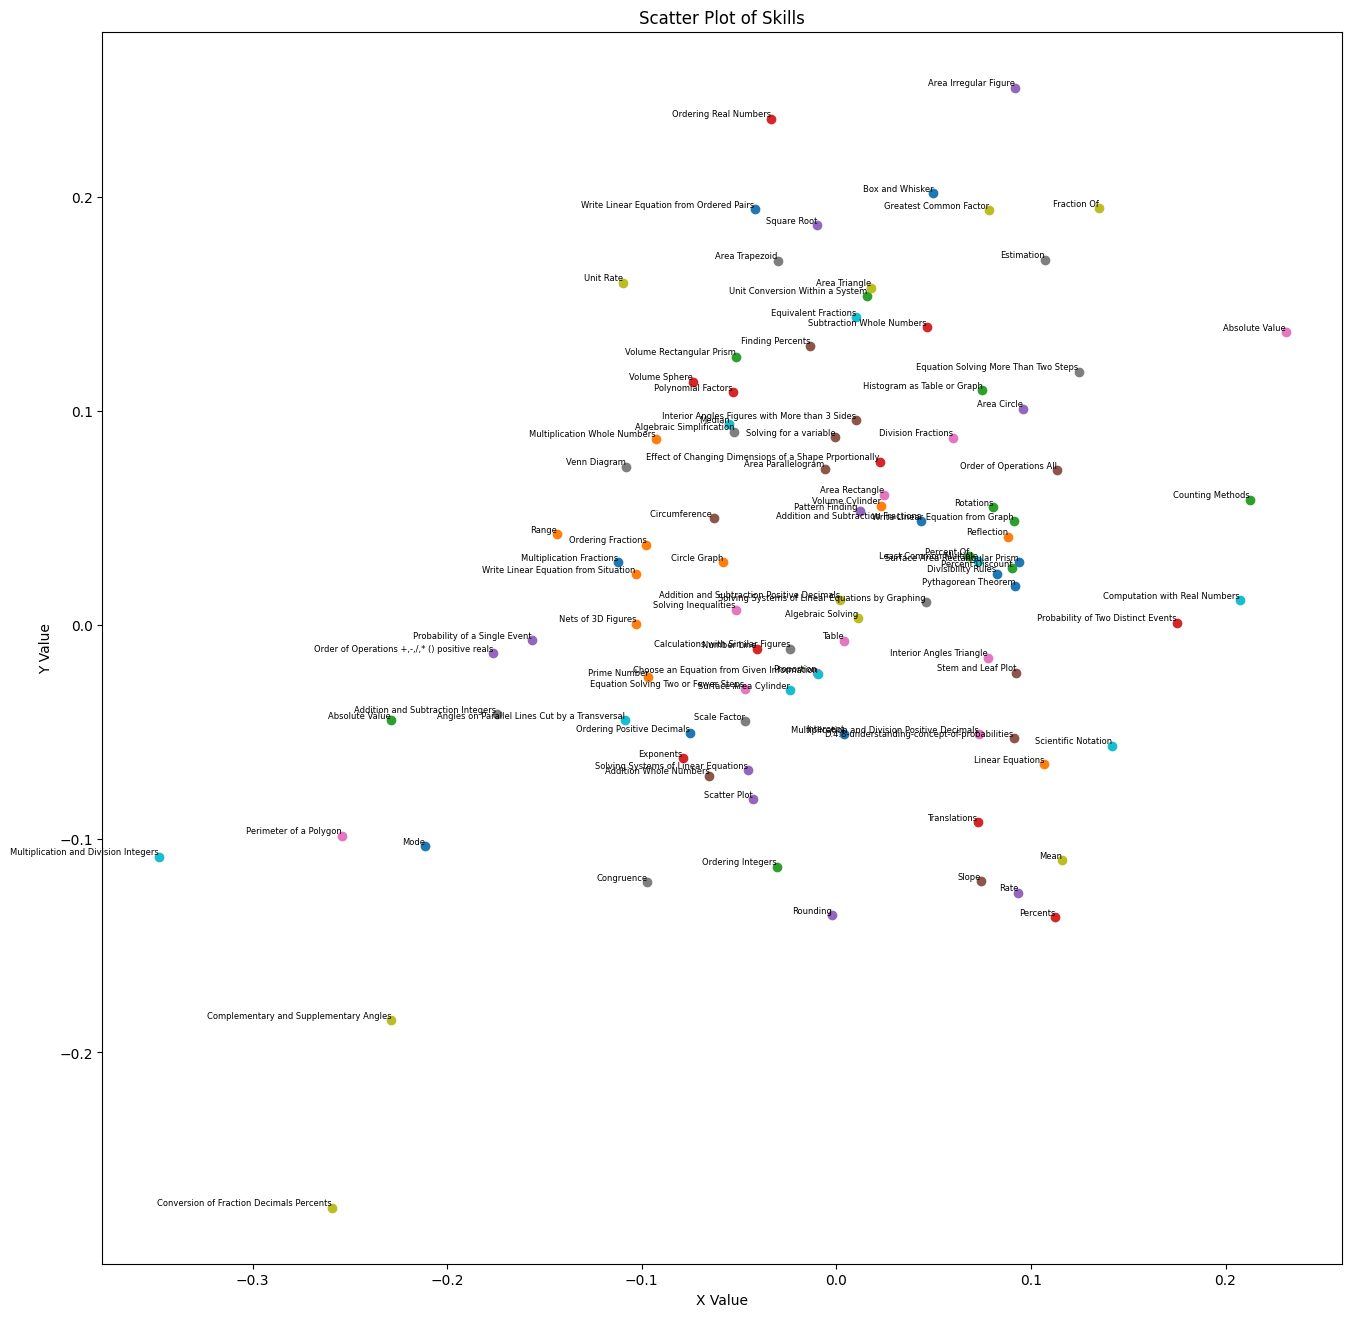

In [26]:
# Create a scatter plot
plt.figure(figsize=(16, 16))

# Plot each scatter point and annotate it with its 'skill_name'
for i, row in df_embeddings.iterrows():
    plt.scatter(row['embed_1'], row['embed_2'])  # You can customize color and marker
    plt.text(row['embed_1'], row['embed_2'], row['skill_name'], fontsize=6, ha='right', va='bottom')

plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.title('Scatter Plot of Skills')
plt.show()


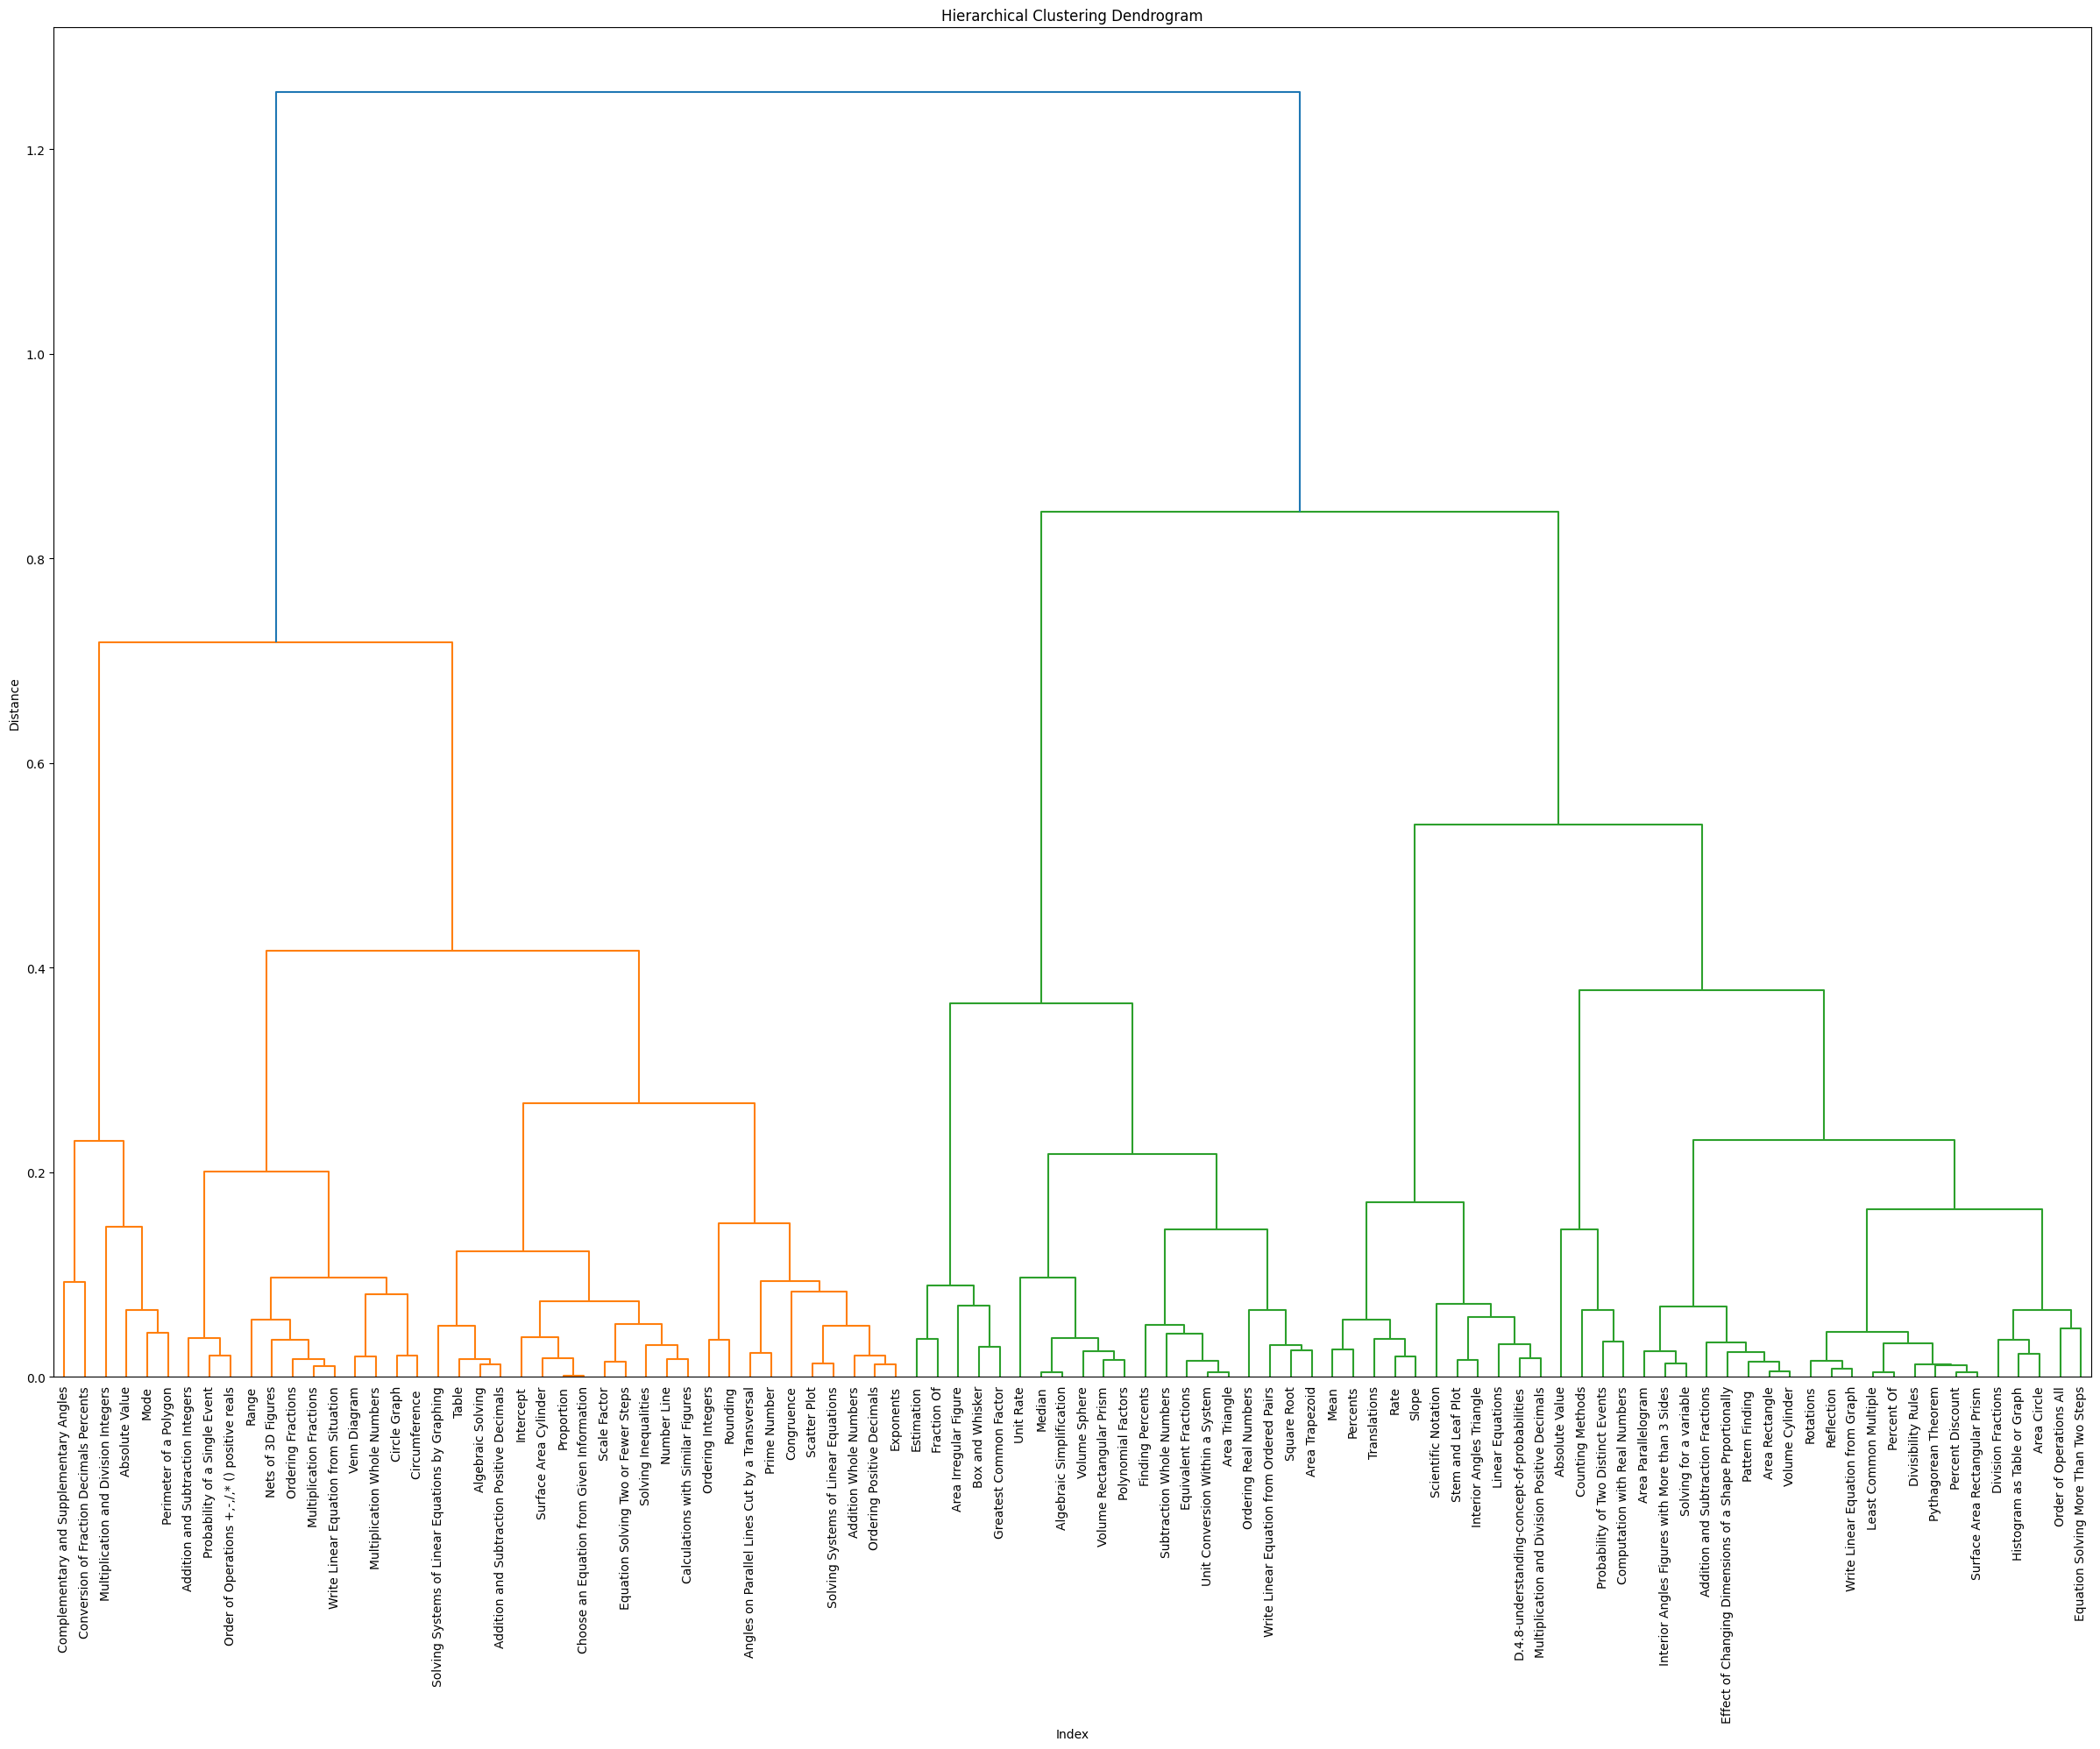

In [27]:
# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_embeddings[['embed_1', 'embed_2']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()
